# AI401 — Intelligent Multi-Agent and Expert Systems
## Experiment 4 — Forward Chaining Inference Engine (Data-Driven Reasoning)

**Name:** Aditya Gaur  
**Roll Number:** U23AI095

### Aim
To implement a forward chaining inference engine and use it to identify an animal from observed features, in the manner of the classic ZOOKEEPER system.

### Assignment coverage
- Forward-chaining inference engine
- Working Memory (WM)
- Conflict-set construction
- First-rule-per-cycle firing
- Firing-sequence recording
- Tiger / giraffe / zebra identification
- No-identification case with the most specific established class
- ALL-applicable-rules-per-cycle variant
- Comparison of firing sequences
- Rule/fact dependency diagram and comparison plot

## 1. Theory

Forward chaining is a **data-driven inference method**. It starts with the facts that are already known and repeatedly applies IF–THEN production rules whose conditions are satisfied.

A production rule has the form

\[
	ext{IF condition}_1 \land condition_2 \land \cdots
	ext{ THEN conclusion}.
\]

Whenever a rule fires, its conclusion is added to Working Memory. That new fact can make additional rules applicable in the next cycle.

The basic recognise–act loop is:

\[
	ext{WM}

ightarrow
	ext{Match}

ightarrow
	ext{Conflict Set}

ightarrow
	ext{Select Rule}

ightarrow
	ext{Fire}

ightarrow
	ext{Add New Fact to WM}.
\]

The assignment specifically asks for the **first applicable rule according to the fixed rule order** in the basic engine. It also asks in Exercise 3 to modify the engine so that **all applicable rules** fire in one cycle.

In [1]:
from dataclasses import dataclass
from typing import Iterable, List, Set, Tuple, Optional
import matplotlib.pyplot as plt

@dataclass(frozen=True)
class Rule:
    rule_id: str
    conditions: Tuple[str, ...]
    conclusion: str
    description: str = ""

    def __str__(self):
        return f"{self.rule_id}: IF {' AND '.join(self.conditions)} THEN {self.conclusion}"


class ForwardChainingEngine:
    def __init__(self, rules: Iterable[Rule]):
        self.rules = list(rules)

    def conflict_set(self, facts: Set[str]) -> List[Rule]:
        return [
            rule for rule in self.rules
            if all(c in facts for c in rule.conditions)
            and rule.conclusion not in facts
        ]

    def run_first(
        self,
        initial_facts: Iterable[str],
        goal: Optional[str] = None,
        max_cycles: int = 100,
    ):
        facts = set(initial_facts)
        sequence = []
        trace = []

        for cycle in range(1, max_cycles + 1):
            conflict = self.conflict_set(facts)

            trace.append({
                "cycle": cycle,
                "facts_before": sorted(facts),
                "conflict_set": [r.rule_id for r in conflict],
            })

            if goal is not None and goal in facts:
                return facts, sequence, trace

            if not conflict:
                return facts, sequence, trace

            rule = conflict[0]
            facts.add(rule.conclusion)
            sequence.append(rule.rule_id)

        raise RuntimeError("Maximum number of cycles exceeded.")

    def run_all(
        self,
        initial_facts: Iterable[str],
        goal: Optional[str] = None,
        max_cycles: int = 100,
    ):
        facts = set(initial_facts)
        sequence = []
        trace = []

        for cycle in range(1, max_cycles + 1):
            conflict = self.conflict_set(facts)

            trace.append({
                "cycle": cycle,
                "facts_before": sorted(facts),
                "conflict_set": [r.rule_id for r in conflict],
            })

            if goal is not None and goal in facts:
                return facts, sequence, trace

            if not conflict:
                return facts, sequence, trace

            newly_added = set()

            for rule in conflict:
                if rule.conclusion not in facts:
                    facts.add(rule.conclusion)
                    newly_added.add(rule.conclusion)
                    sequence.append(rule.rule_id)

            if not newly_added:
                raise RuntimeError("No new facts were generated.")

        raise RuntimeError("Maximum number of cycles exceeded.")


print("Forward-chaining engine defined.")

Forward-chaining engine defined.


## 2. Knowledge Base

The assignment does not prescribe a fixed animal knowledge base, so a small ZOOKEEPER-style knowledge base is used.

The main chain deliberately follows the structure highlighted in the assignment:

\[
R1 
ightarrow R4 
ightarrow R6.
\]

The rules are:

\[
R1:\ has\_fur \land warm\_blooded 
ightarrow mammal
\]

\[
R4:\ mammal \land eats\_meat 
ightarrow carnivore
\]

\[
R6:\ carnivore \land yellow\_fur \land black\_stripes 
ightarrow tiger
\]

Exercise 1 adds:

\[
R7:\ long\_neck \land long\_legs 
ightarrow giraffe
\]

\[
R8:\ black\_stripes \land not\_carnivore 
ightarrow zebra.
\]

The zebra case uses an **explicit negative fact** `not_carnivore`; no closed-world assumption is made.

In [2]:
rules = [
    Rule("R1", ("has_fur", "warm_blooded"), "mammal",
         "Infer mammal."),
    Rule("R2", ("mammal", "has_four_legs"), "terrestrial_animal",
         "Infer terrestrial animal."),
    Rule("R3", ("mammal", "lays_eggs"), "egg_laying_mammal",
         "Additional class rule."),
    Rule("R4", ("mammal", "eats_meat"), "carnivore",
         "Infer carnivore."),
    Rule("R5", ("mammal", "has_hoof"), "hoofed_mammal",
         "Infer hoofed mammal."),
    Rule("R6", ("carnivore", "yellow_fur", "black_stripes"), "tiger",
         "Identify tiger."),
    Rule("R7", ("long_neck", "long_legs"), "giraffe",
         "Identify giraffe."),
    Rule("R8", ("black_stripes", "not_carnivore"), "zebra",
         "Identify zebra."),
]

engine = ForwardChainingEngine(rules)

print("RULE BASE")
print("=" * 80)
for rule in rules:
    print(rule)

RULE BASE
R1: IF has_fur AND warm_blooded THEN mammal
R2: IF mammal AND has_four_legs THEN terrestrial_animal
R3: IF mammal AND lays_eggs THEN egg_laying_mammal
R4: IF mammal AND eats_meat THEN carnivore
R5: IF mammal AND has_hoof THEN hoofed_mammal
R6: IF carnivore AND yellow_fur AND black_stripes THEN tiger
R7: IF long_neck AND long_legs THEN giraffe
R8: IF black_stripes AND not_carnivore THEN zebra


## 3. Algorithm — First Applicable Rule

1. Initialise WM with the observed features.
2. Find every rule whose conditions are satisfied and whose conclusion is new.
3. If the conflict set is empty, stop.
4. Otherwise choose the **first rule** in the fixed rule order.
5. Add its conclusion to WM.
6. Record the rule identifier.
7. Repeat until the goal animal is identified or no new rule can fire.
8. Report the final WM, firing sequence and identification.

In [3]:
def display_trace(trace):
    for item in trace:
        print(
            f"Cycle {item['cycle']}: "
            f"conflict set = {item['conflict_set']}"
        )


tiger_initial = {
    "has_fur",
    "warm_blooded",
    "eats_meat",
    "yellow_fur",
    "black_stripes",
}

tiger_facts, tiger_sequence, tiger_trace = engine.run_first(
    tiger_initial,
    goal="tiger",
)

print("MAIN DEMONSTRATION — TIGER")
print("=" * 60)
print("Initial facts:", sorted(tiger_initial))
display_trace(tiger_trace)
print("Firing sequence:", " -> ".join(tiger_sequence))
print("Final facts:", sorted(tiger_facts))
print("Identified animal:", "tiger" if "tiger" in tiger_facts else "none")

MAIN DEMONSTRATION — TIGER
Initial facts: ['black_stripes', 'eats_meat', 'has_fur', 'warm_blooded', 'yellow_fur']
Cycle 1: conflict set = ['R1']
Cycle 2: conflict set = ['R4']
Cycle 3: conflict set = ['R6']
Cycle 4: conflict set = []
Firing sequence: R1 -> R4 -> R6
Final facts: ['black_stripes', 'carnivore', 'eats_meat', 'has_fur', 'mammal', 'tiger', 'warm_blooded', 'yellow_fur']
Identified animal: tiger


## 4. Main Result — R1 → R4 → R6

The engine starts from observations, not from the final answer.

\[
\{has\_fur,\ warm\_blooded\}
\overset{R1}{\longrightarrow}
mammal
\]

then:

\[
\{mammal,\ eats\_meat\}
\overset{R4}{\longrightarrow}
carnivore
\]

then:

\[
\{carnivore,\ yellow\_fur,\ black\_stripes\}
\overset{R6}{\longrightarrow}
tiger.
\]

Thus the recorded rule chain is:

\[
oxed{R1 
ightarrow R4 
ightarrow R6}.
\]

This is the central example of **data-driven reasoning**.

In [4]:
assert tiger_sequence == ["R1", "R4", "R6"]
assert "tiger" in tiger_facts

print("Verified firing sequence:", " -> ".join(tiger_sequence))
print("Verified identification: tiger")

Verified firing sequence: R1 -> R4 -> R6
Verified identification: tiger


## 5. Dependency Diagram

The graph below visualises how rule conclusions become facts used by later rules.

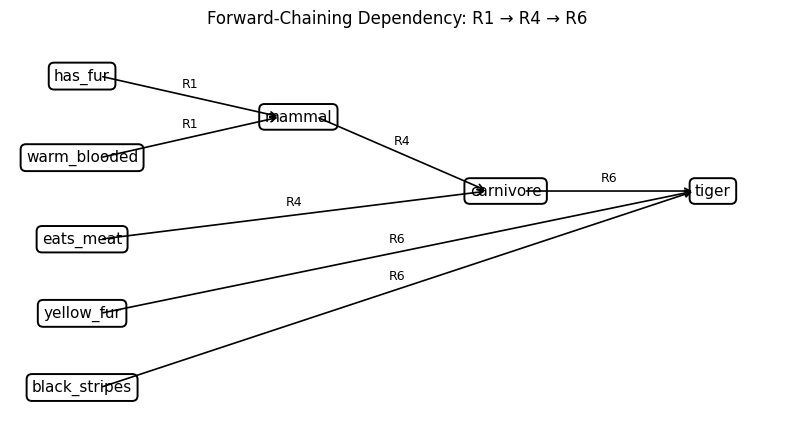

In [5]:
nodes = {
    "has_fur": (0, 2.2),
    "warm_blooded": (0, 1.1),
    "eats_meat": (0, 0.0),
    "yellow_fur": (0, -1.0),
    "black_stripes": (0, -2.0),
    "mammal": (2.4, 1.65),
    "carnivore": (4.7, 0.65),
    "tiger": (7.0, 0.65),
}

edges = [
    ("has_fur", "mammal", "R1"),
    ("warm_blooded", "mammal", "R1"),
    ("mammal", "carnivore", "R4"),
    ("eats_meat", "carnivore", "R4"),
    ("carnivore", "tiger", "R6"),
    ("yellow_fur", "tiger", "R6"),
    ("black_stripes", "tiger", "R6"),
]

fig, ax = plt.subplots(figsize=(10, 5.2))

for label, (x, y) in nodes.items():
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.35", fill=False, linewidth=1.4),
    )

for src, dst, rid in edges:
    x1, y1 = nodes[src]
    x2, y2 = nodes[dst]

    ax.annotate(
        "",
        xy=(x2 - 0.20, y2),
        xytext=(x1 + 0.20, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.2),
    )

    ax.text(
        (x1 + x2) / 2,
        (y1 + y2) / 2 + 0.13,
        rid,
        ha="center",
        fontsize=9,
    )

ax.set_xlim(-0.8, 7.8)
ax.set_ylim(-2.6, 2.8)
ax.axis("off")
ax.set_title("Forward-Chaining Dependency: R1 → R4 → R6")
plt.show()

# Exercise 1 — Identify Tiger, Giraffe and Zebra

The assignment asks for:
- **tiger**
- **giraffe** from long neck and long legs
- **zebra** from black stripes and not carnivore.

The three cases use the same inference engine.

In [6]:
exercise1_cases = {
    "Tiger": (
        {"has_fur", "warm_blooded", "eats_meat", "yellow_fur", "black_stripes"},
        "tiger",
    ),
    "Giraffe": (
        {"long_neck", "long_legs"},
        "giraffe",
    ),
    "Zebra": (
        {"black_stripes", "not_carnivore"},
        "zebra",
    ),
}

exercise1_results = {}

for animal, (facts, goal) in exercise1_cases.items():
    result = engine.run_first(facts, goal=goal)
    exercise1_results[animal] = result

    final_facts, sequence, trace = result

    print("=" * 65)
    print(animal)
    print("Initial facts :", sorted(facts))
    print("Firing sequence:", " -> ".join(sequence) or "(none)")
    print("Final facts   :", sorted(final_facts))
    print("Identification :", goal if goal in final_facts else "not established")

Tiger
Initial facts : ['black_stripes', 'eats_meat', 'has_fur', 'warm_blooded', 'yellow_fur']
Firing sequence: R1 -> R4 -> R6
Final facts   : ['black_stripes', 'carnivore', 'eats_meat', 'has_fur', 'mammal', 'tiger', 'warm_blooded', 'yellow_fur']
Identification : tiger
Giraffe
Initial facts : ['long_legs', 'long_neck']
Firing sequence: R7
Final facts   : ['giraffe', 'long_legs', 'long_neck']
Identification : giraffe
Zebra
Initial facts : ['black_stripes', 'not_carnivore']
Firing sequence: R8
Final facts   : ['black_stripes', 'not_carnivore', 'zebra']
Identification : zebra


### Exercise 1 interpretation

The tiger is obtained through the multi-step chain:

\[
features 
ightarrow mammal 
ightarrow carnivore 
ightarrow tiger.
\]

The giraffe and zebra are obtained directly from their characteristic observations.

The zebra case is intentionally explicit:

\[
black\_stripes \land not\_carnivore

ightarrow zebra.
\]

The engine does not infer `not_carnivore` merely because `carnivore` is absent; the negative fact is explicitly supplied.

In [7]:
assert "tiger" in exercise1_results["Tiger"][0]
assert "giraffe" in exercise1_results["Giraffe"][0]
assert "zebra" in exercise1_results["Zebra"][0]

print("Tiger, giraffe and zebra identification verified.")

Tiger, giraffe and zebra identification verified.


# Exercise 2 — No Identification Rule Fires

We now give facts that allow the engine to derive a class but do not support any specific animal:

\[
has\_fur,\ warm\_blooded,\ has\_four\_legs.
\]

The engine can derive:

\[
R1 
ightarrow mammal
\]

and then:

\[
R2 
ightarrow terrestrial\_animal.
\]

No animal-identification rule becomes applicable.

Therefore the correct answer is not an invented animal. The most specific established class is:

\[
oxed{terrestrial\_animal}.
\]

In [8]:
exercise2_initial = {
    "has_fur",
    "warm_blooded",
    "has_four_legs",
}

exercise2_facts, exercise2_sequence, exercise2_trace = engine.run_first(
    exercise2_initial
)

display_trace(exercise2_trace)

print("Firing sequence:", " -> ".join(exercise2_sequence))
print("Final facts:", sorted(exercise2_facts))

animal_names = {"tiger", "giraffe", "zebra"}
identified = sorted(animal_names.intersection(exercise2_facts))

class_specificity = {
    "mammal": 1,
    "terrestrial_animal": 2,
    "egg_laying_mammal": 2,
    "carnivore": 2,
    "hoofed_mammal": 2,
}

established_classes = [
    fact for fact in exercise2_facts
    if fact in class_specificity
]

most_specific = max(
    established_classes,
    key=lambda x: class_specificity[x]
)

print("Identified animals:", identified if identified else "None")
print("Most specific class established:", most_specific)

assert not identified
assert most_specific == "terrestrial_animal"

Cycle 1: conflict set = ['R1']
Cycle 2: conflict set = ['R2']
Cycle 3: conflict set = []
Firing sequence: R1 -> R2
Final facts: ['has_four_legs', 'has_fur', 'mammal', 'terrestrial_animal', 'warm_blooded']
Identified animals: None
Most specific class established: terrestrial_animal


# Exercise 3 — Fire ALL Applicable Rules per Cycle

The basic engine fires **one** rule from the conflict set per cycle.

For this exercise, the engine is changed so that every rule in the current conflict set fires once during the same cycle.

### First-rule strategy

\[
	ext{Match}

ightarrow
	ext{Conflict Set}

ightarrow
	ext{First Rule}

ightarrow
	ext{Fire}

ightarrow
	ext{Match Again}
\]

### All-rules strategy

\[
	ext{Match}

ightarrow
	ext{Conflict Set}

ightarrow
	ext{Fire All}

ightarrow
	ext{Next Cycle}.
\]

The firing sequence can therefore change because several independent conclusions can be added together.

In [9]:
comparison_initial = {
    "has_fur",
    "warm_blooded",
    "has_four_legs",
    "lays_eggs",
}

first_facts, first_sequence, first_trace = engine.run_first(
    comparison_initial
)

all_facts, all_sequence, all_trace = engine.run_all(
    comparison_initial
)

print("FIRST-RULE STRATEGY")
print("=" * 65)
display_trace(first_trace)
print("Sequence:", " -> ".join(first_sequence))
print("Cycles:", len(first_sequence))
print("Final facts:", sorted(first_facts))

print()
print("ALL-RULES STRATEGY")
print("=" * 65)
display_trace(all_trace)
print("Sequence:", " -> ".join(all_sequence))
print("Cycles:", len(all_trace))
print("Final facts:", sorted(all_facts))

print()
print("Same final closure:", first_facts == all_facts)

assert first_facts == all_facts

FIRST-RULE STRATEGY
Cycle 1: conflict set = ['R1']
Cycle 2: conflict set = ['R2', 'R3']
Cycle 3: conflict set = ['R3']
Cycle 4: conflict set = []
Sequence: R1 -> R2 -> R3
Cycles: 3
Final facts: ['egg_laying_mammal', 'has_four_legs', 'has_fur', 'lays_eggs', 'mammal', 'terrestrial_animal', 'warm_blooded']

ALL-RULES STRATEGY
Cycle 1: conflict set = ['R1']
Cycle 2: conflict set = ['R2', 'R3']
Cycle 3: conflict set = []
Sequence: R1 -> R2 -> R3
Cycles: 3
Final facts: ['egg_laying_mammal', 'has_four_legs', 'has_fur', 'lays_eggs', 'mammal', 'terrestrial_animal', 'warm_blooded']

Same final closure: True


## Exercise 3 — Comparison

For this monotonic knowledge base, both strategies eventually derive the same supported facts.

The difference is **how quickly and in what order the facts are derived**:

- The first-rule strategy may need several cycles because only one rule fires per cycle.
- The all-rules strategy can add multiple independent conclusions in one cycle.
- Consequently, the firing sequences and number of cycles can differ even when the final closure is the same.

This is a useful distinction between **inference order** and **final inferred knowledge**.

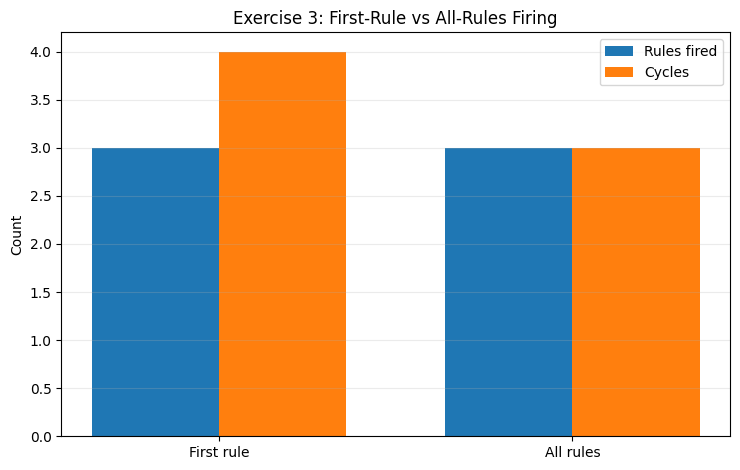

In [10]:
strategies = ["First rule", "All rules"]
rule_counts = [len(first_sequence), len(all_sequence)]
cycle_counts = [len(first_trace), len(all_trace)]

fig, ax = plt.subplots(figsize=(7.5, 4.8))

x = range(len(strategies))
width = 0.36

ax.bar(
    [i - width / 2 for i in x],
    rule_counts,
    width,
    label="Rules fired",
)

ax.bar(
    [i + width / 2 for i in x],
    cycle_counts,
    width,
    label="Cycles",
)

ax.set_xticks(list(x), strategies)
ax.set_ylabel("Count")
ax.set_title("Exercise 3: First-Rule vs All-Rules Firing")
ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# 6. Observations

1. Forward chaining is **data-driven**: it starts with observed features and derives new facts from applicable rules.

2. The main identification demonstrates abstraction through chaining:
   `features → mammal → carnivore → tiger`.

3. Every fired rule adds its conclusion to Working Memory, so newly derived facts can trigger additional rules.

4. The conflict set changes after each update of Working Memory because a newly derived fact may make another rule applicable.

5. When no identification rule can fire, the engine should not invent an animal. It reports the most specific class that is actually supported by the available facts.

6. Firing all applicable rules per cycle changes the firing sequence and can reduce the number of cycles needed to reach the same monotonic closure.

7. The recorded rule sequence is useful because it explains how the engine moved from observations to the final identification.

# 7. Conclusion

A forward chaining inference engine was implemented using a production-rule knowledge base and Working Memory. The engine constructs a conflict set, selects the first rule according to rule order, fires it, adds its conclusion to Working Memory, and repeats until an animal is identified or no new rule can fire.

The main ZOOKEEPER-style case produced the expected chain:

\[
oxed{R1 
ightarrow R4 
ightarrow R6}.
\]

The knowledge base was extended to identify tiger, giraffe and zebra. A no-identification case was handled by reporting the most specific supported class, `terrestrial_animal`. Finally, the engine was modified to fire all applicable rules per cycle and the resulting firing behavior was compared with the original first-rule strategy.

# 8. Verification

In [11]:
# Comprehensive final checks.
assert tiger_sequence == ["R1", "R4", "R6"]
assert "tiger" in exercise1_results["Tiger"][0]
assert "giraffe" in exercise1_results["Giraffe"][0]
assert "zebra" in exercise1_results["Zebra"][0]
assert not {"tiger", "giraffe", "zebra"}.intersection(exercise2_facts)
assert most_specific == "terrestrial_animal"
assert first_facts == all_facts

print("✓ R1 → R4 → R6 verified")
print("✓ Tiger verified")
print("✓ Giraffe verified")
print("✓ Zebra verified")
print("✓ No-identification case verified")
print("✓ Most-specific class reporting verified")
print("✓ First-rule/all-rules closure comparison verified")
print()
print("ALL EXPERIMENT TASKS PASSED.")

✓ R1 → R4 → R6 verified
✓ Tiger verified
✓ Giraffe verified
✓ Zebra verified
✓ No-identification case verified
✓ Most-specific class reporting verified
✓ First-rule/all-rules closure comparison verified

ALL EXPERIMENT TASKS PASSED.
